<a href="https://colab.research.google.com/github/Carmen10-171/01MIAR_ABR26/blob/main/01MIAR_Exam_02_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen Segunda Convocatoria Franja Mañana

In [ ]:
# Your imports HERE !!!!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Tienda Online

Adjunto al examen hay tres ficheros *CSV* que describen el funcionamiento de una tienda online.

- *clientes.csv*, describe la lista de clientes de la tienda
  - `id_cliente`, `nombre`, `ciudad`, `edad`, `fecha_alta`
- *productos.csv*, la lista de productos a la venta actualmente en la tienda
  - `id_producto`, `nombre_producto`, `categoria`, `precio`
- *pedidos.csv*, es el histórico de pedidos que los clientes han realizado en la tienda
  - `id_pedido`, `id_cliente`, `id_producto`, `cantidad`, `fecha_pedido`

Cada fichero/tabla tiene un campo (`id_xxxx`) que identifica de manera única a cada registro. Por tanto la tabla de pedidos, es una relación que combina el hecho de que un cliente `id_cliente` haya realizado un pedido en una `fecha_pedido` de una `cantidad` de un producto `id_producto`.

Algunos pedidos pueden hacer referencia a clientes o productos que *no existan* en los ficheros/tablas maestras de datos de clientes o productos. Pueden haberse producido bajas de clientes, productos descatalogados, errores de registro,...

## Criterios generales

- Código funcional que resuelve lo pedido, usando las librerías y métodos de manera correcta y óptima: puntuación completa del apartado.
- Código funcional que resuelve lo pedido, usando bucles o métodos iterativos poco eficientes: 50% del apartado.

## 01 - Exploración de los datos (2pt)

### 01.A (0.5pt)

Carga los tres ficheros en sus correspondientes *DataFrame*.

In [ ]:
# Your solution Here

# Cargamos los tres ficheros CSV en sus correspondientes DataFrames
clientes = pd.read_csv('clientes.csv')
productos = pd.read_csv('productos.csv')
pedidos = pd.read_csv('pedidos.csv')

# Un vistazo rápido a cada uno para comprobar que se han cargado bien
display(clientes.head(5))
display(productos.head(5))
display(pedidos.head(5))


,id_cliente,nombre,ciudad,edad,fecha_alta
0,1,Luis Vázquez,Sevilla,68,2023-07-09
1,2,Adrián Díaz,Murcia,67,2023-12-03
2,3,Laura Gil,Madrid,44,2023-10-28
3,4,Luis Torres,Murcia,19,2022-05-02
4,5,Elena Martínez,Zaragoza,49,2024-01-14


,id_producto,nombre_producto,categoria,precio
0,1,Auriculares BT,Electrónica,41.21
1,2,Cargador USB-C,Electrónica,234.35
2,3,Teclado mecánico,Electrónica,112.29
3,4,Ratón inalámbrico,Electrónica,98.91
4,5,Altavoz portátil,Electrónica,183.77


,id_pedido,id_cliente,id_producto,cantidad,fecha_pedido
0,1,8,12,5.0,2025-06-13
1,2,141,16,3.0,2025-05-20
2,3,110,30,1.0,2024-04-08
3,4,46,25,1.0,2024-11-21
4,5,125,22,2.0,2024-02-27


In [ ]:
df_clientes =pd.read_csv('clientes.csv')
df_clientes.head(5)


,id_cliente,nombre,ciudad,edad,fecha_alta
0,1,Luis Vázquez,Sevilla,68,2023-07-09
1,2,Adrián Díaz,Murcia,67,2023-12-03
2,3,Laura Gil,Madrid,44,2023-10-28
3,4,Luis Torres,Murcia,19,2022-05-02
4,5,Elena Martínez,Zaragoza,49,2024-01-14


In [ ]:
df_pedidos=pd.read_csv('pedidos.csv')
df_pedidos.head(5)

,id_pedido,id_cliente,id_producto,cantidad,fecha_pedido
0,1,8,12,5.0,2025-06-13
1,2,141,16,3.0,2025-05-20
2,3,110,30,1.0,2024-04-08
3,4,46,25,1.0,2024-11-21
4,5,125,22,2.0,2024-02-27


In [ ]:
df_productos=pd.read_csv('productos.csv')
df_productos.head(5)

,id_producto,nombre_producto,categoria,precio
0,1,Auriculares BT,Electrónica,41.21
1,2,Cargador USB-C,Electrónica,234.35
2,3,Teclado mecánico,Electrónica,112.29
3,4,Ratón inalámbrico,Electrónica,98.91
4,5,Altavoz portátil,Electrónica,183.77


### 01.B (0.5pt)

Muestra cuantos registros, los tipos de datos y el número de valores nulos por columna de las tres tablas.

In [ ]:
# Your solution Here
#tabla clientes
for nombre, df in {
    'CLIENTES': df_clientes,
    'PEDIDOS': df_pedidos,
    'PRODUCTOS': df_productos
}.items():

    print(f"\n=== {nombre} ===")
    print(f"Número de registros: {df.shape[0]}")

    resumen = pd.DataFrame({
        'Columna': df.columns,
        'Tipo de dato': df.dtypes.values,
        'Valores nulos': df.isnull().sum().values
    })

    display(resumen)



=== CLIENTES ===
Número de registros: 150


,Columna,Tipo de dato,Valores nulos
0,id_cliente,int64,0
1,nombre,str,0
2,ciudad,str,0
3,edad,int64,0
4,fecha_alta,str,0



=== PEDIDOS ===
Número de registros: 900


,Columna,Tipo de dato,Valores nulos
0,id_pedido,int64,0
1,id_cliente,int64,0
2,id_producto,int64,0
3,cantidad,float64,21
4,fecha_pedido,str,0



=== PRODUCTOS ===
Número de registros: 30


,Columna,Tipo de dato,Valores nulos
0,id_producto,int64,0
1,nombre_producto,str,0
2,categoria,str,0
3,precio,float64,0


### 01.C (0.5pt)

- ¿Cuantos clientes distintos hay por ciudad?
- ¿Cuantos productos distintos hay por categoria?

In [ ]:
# Clientes por ciudad
clientes_por_ciudad = (
    clientes.groupby('ciudad')['id_cliente']
    .nunique()
    .reset_index(name='num_clientes')
    .sort_values('num_clientes', ascending=False)
)

display(clientes_por_ciudad)

# Productos por categoría
productos_por_categoria = (
    productos.groupby('categoria')['id_producto']
    .nunique()
    .reset_index(name='num_productos')
    .sort_values('num_productos', ascending=False)
)

display(productos_por_categoria)



,ciudad,num_clientes
1,Barcelona,21
8,Vigo,20
6,Sevilla,17
7,Valencia,16
4,Murcia,15
3,Madrid,15
9,Zaragoza,14
0,Alicante,13
5,Málaga,10
2,Bilbao,9


,categoria,num_productos
0,Deporte,6
1,Electrónica,6
2,Hogar,6
3,Libros,6
4,Ropa,6


### 01.D (0.5pt)

Comprueba si hay algún cliente duplicado en la tabla de clientes (el campo *id_cliente* debería ser único en toda la tabla) y si hay algún producto duplicado en la tabla de productos.

In [ ]:
# =====================================
# Clientes duplicados
# =====================================

clientes_duplicados = clientes[
    clientes.duplicated(subset='id_cliente', keep=False)
].sort_values('id_cliente')

print(f"Clientes duplicados encontrados: {clientes_duplicados['id_cliente'].nunique()}")

if not clientes_duplicados.empty:
    display(clientes_duplicados)
else:
    print("No existen clientes duplicados.")


# =====================================
# Productos duplicados
# =====================================

productos_duplicados = productos[
    productos.duplicated(subset='id_producto', keep=False)
].sort_values('id_producto')

print(f"Productos duplicados encontrados: {productos_duplicados['id_producto'].nunique()}")

if not productos_duplicados.empty:
    display(productos_duplicados)
else:
    print("No existen productos duplicados.")


Clientes duplicados encontrados: 0
No existen clientes duplicados.
Productos duplicados encontrados: 0
No existen productos duplicados.


## 02 - Merge / Join (3pt)

### 02.A (0.7pt)

Antes de unir las tablas, calcula cuántos pedidos tienen un *id_cliente* que no existe en la tabla de clientes, y cuántos pedidos tienen un *id_producto* que no existe en la tabla de productos.

In [ ]:
# Your solution Here
# =====================================
# Pedidos con clientes inexistentes
# =====================================

pedidos_sin_cliente = pedidos[
    ~pedidos['id_cliente'].isin(clientes['id_cliente'])
]

print(f"Pedidos con id_cliente inexistente: {len(pedidos_sin_cliente)}")


# =====================================
# Pedidos con productos inexistentes
# =====================================

pedidos_sin_producto = pedidos[
    ~pedidos['id_producto'].isin(productos['id_producto'])
]

print(f"Pedidos con id_producto inexistente: {len(pedidos_sin_producto)}")

Pedidos con id_cliente inexistente: 58
Pedidos con id_producto inexistente: 99


### 02.B (0.8pt)

Realiza un merge de la tabla de pedidos con la de clientes, usando el campo adecuado y un left join. Después comprueba cuántas filas del resultado tienen el campo `nombre` del cliente nulo (es decir, pedidos huerfanos de cliente) y verifica que coincide con el número calculado en el apartado anterior.

In [ ]:
# Your solution Here

# Merge LEFT JOIN entre pedidos y clientes
pedidos_clientes = pedidos.merge(
    clientes,
    on='id_cliente',
    how='left'
)

# Número de pedidos huérfanos (sin cliente asociado)
pedidos_huerfanos = pedidos_clientes['nombre'].isnull().sum()

print(f"Pedidos huérfanos de cliente: {pedidos_huerfanos}")

# Mostrar algunas filas huérfanas
display(
    pedidos_clientes[pedidos_clientes['nombre'].isnull()]
    .head()
)




Pedidos huérfanos de cliente: 58


,id_pedido,id_cliente,id_producto,cantidad,fecha_pedido,nombre,ciudad,edad,fecha_alta
9,10,160,18,5.0,2025-05-30,NaN,NaN,NaN,NaN
40,41,157,32,3.0,2025-04-24,NaN,NaN,NaN,NaN
42,43,155,22,5.0,2025-06-22,NaN,NaN,NaN,NaN
50,51,155,14,1.0,2024-08-24,NaN,NaN,NaN,NaN
83,84,157,10,3.0,2024-08-19,NaN,NaN,NaN,NaN


### 02.C (0.8pt)

Sobre el dataframe obtenido en el punto anterior, realiza un segundo merge con la tabla de productos, usando también un left join, para obtener una tabla completa con la información del cliente y producto en cada fila.

In [ ]:
# Your solution Here
# Merge con la tabla de productos
tabla_completa = pedidos_clientes.merge(
    productos,
    on='id_producto',
    how='left'
)

# Visualizar las primeras filas
display(tabla_completa.head())

,id_pedido,id_cliente,id_producto,cantidad,fecha_pedido,nombre,ciudad,edad,fecha_alta,nombre_producto,categoria,precio
0,1,8,12,5.0,2025-06-13,Nuria Vázquez,Zaragoza,51.0,2023-04-08,Organizador armario,Hogar,180.85
1,2,141,16,3.0,2025-05-20,Javier Moreno,Vigo,60.0,2024-01-06,Chaqueta impermeable,Ropa,161.08
2,3,110,30,1.0,2024-04-08,Laura Serrano,Madrid,63.0,2023-02-24,Poesía contemporánea,Libros,249.27
3,4,46,25,1.0,2024-11-21,Laura Ramos,Valencia,39.0,2022-10-23,Novela histórica,Libros,113.37
4,5,125,22,2.0,2024-02-27,Iván García,Bilbao,18.0,2023-12-09,Balón fútbol,Deporte,207.22


In [ ]:
print("Número de filas:", tabla_completa.shape[0])
print("Número de columnas:", tabla_completa.shape[1])

display(tabla_completa.head())

Número de filas: 900
Número de columnas: 12


,id_pedido,id_cliente,id_producto,cantidad,fecha_pedido,nombre,ciudad,edad,fecha_alta,nombre_producto,categoria,precio
0,1,8,12,5.0,2025-06-13,Nuria Vázquez,Zaragoza,51.0,2023-04-08,Organizador armario,Hogar,180.85
1,2,141,16,3.0,2025-05-20,Javier Moreno,Vigo,60.0,2024-01-06,Chaqueta impermeable,Ropa,161.08
2,3,110,30,1.0,2024-04-08,Laura Serrano,Madrid,63.0,2023-02-24,Poesía contemporánea,Libros,249.27
3,4,46,25,1.0,2024-11-21,Laura Ramos,Valencia,39.0,2022-10-23,Novela histórica,Libros,113.37
4,5,125,22,2.0,2024-02-27,Iván García,Bilbao,18.0,2023-12-09,Balón fútbol,Deporte,207.22


### 02.D (0.7pt)

A partir de este último dataframe con los datos completos, crea una versión limpia que se llame *`pedidos_validos`* y contenga solo los pedidos con cliente y producto conocidos (sin nulos en el campo `nombre` ni en `nombre_producto`).

Verificar cuantos pedidos validos quedan finalmente.

Escribe una pequeña interpretación de porque se elige un left join en este caso y se filtra después, en lugar de hacer directamente un inner join. ¿Hay alguna ventaja en hacerlo en dos pasos?

In [ ]:
# Your solution Here
# Crear dataframe limpio con pedidos válidos
pedidos_validos = tabla_completa.dropna(
    subset=['nombre', 'nombre_producto']
)

# Verificar cuántos pedidos válidos quedan
print("Número de pedidos válidos:", len(pedidos_validos))

# Mostrar una muestra
display(pedidos_validos.head())


Número de pedidos válidos: 749


,id_pedido,id_cliente,id_producto,cantidad,fecha_pedido,nombre,ciudad,edad,fecha_alta,nombre_producto,categoria,precio
0,1,8,12,5.0,2025-06-13,Nuria Vázquez,Zaragoza,51.0,2023-04-08,Organizador armario,Hogar,180.85
1,2,141,16,3.0,2025-05-20,Javier Moreno,Vigo,60.0,2024-01-06,Chaqueta impermeable,Ropa,161.08
2,3,110,30,1.0,2024-04-08,Laura Serrano,Madrid,63.0,2023-02-24,Poesía contemporánea,Libros,249.27
3,4,46,25,1.0,2024-11-21,Laura Ramos,Valencia,39.0,2022-10-23,Novela histórica,Libros,113.37
4,5,125,22,2.0,2024-02-27,Iván García,Bilbao,18.0,2023-12-09,Balón fútbol,Deporte,207.22


Se utiliza primero un left join porque permite conservar todos los pedidos, incluso aquellos que no tienen un cliente o producto asociado. De esta forma es posible identificar y cuantificar los registros huérfanos durante el proceso de limpieza.

Si se utilizara directamente un inner join, los pedidos sin correspondencia en las tablas de clientes o productos desaparecerían automáticamente y no podríamos saber cuántos registros se han perdido ni analizar la calidad de los datos.

La ventaja de hacerlo en dos pasos es que permite:

Detectar pedidos huérfanos de clientes o productos.
Verificar la integridad de los datos.
Documentar cuántos registros se eliminan durante la limpieza.
Mantener un mayor control sobre el proceso de depuración.

Una vez realizado este análisis, el resultado final (pedidos_validos) es equivalente a trabajar únicamente con los registros que tienen cliente y producto válidos.

## 03 - NumPy (2pt)

Para este punto usa siempre este último dataframe con todos los datos limpios *`pedidos_validos`*.

### 03.A (0.6pt)

Calcula la media, mediana y desviación standard de la columna `cantidad` usando solo funciones de NumPy. Puede haber datos nulos en esa columna, no deberías tenerlos en cuenta para estos cálculos.

In [ ]:
# Your solution Here
import numpy as np

# Convertir la columna a array de NumPy
cantidad = pedidos_validos['cantidad'].to_numpy()

# Cálculos ignorando NaN
media = np.nanmean(cantidad)
mediana = np.nanmedian(cantidad)
desviacion_std = np.nanstd(cantidad)

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar: {desviacion_std:.2f}")




Media: 2.98
Mediana: 3.00
Desviación estándar: 1.42


### 03.B (0.7pt)

Crea una nueva columna llamada `importe` en el dataframe limpio que sea el resultado de multiplicar `cantidad` por `precio`, usando funciones de NumPy. Si la `cantidad` es nula, entonces `importe` debería quedara también nulo.

In [ ]:
# Your solution Here
import numpy as np

pedidos_validos['importe'] = np.where(
    pedidos_validos['cantidad'].isna(),
    np.nan,
    pedidos_validos['cantidad'] * pedidos_validos['precio']
)

display(pedidos_validos[['cantidad', 'precio', 'importe']].head())


,cantidad,precio,importe
0,5.0,180.85,904.25
1,3.0,161.08,483.24
2,1.0,249.27,249.27
3,1.0,113.37,113.37
4,2.0,207.22,414.44


In [ ]:
# Comprobar que se han mantenido los nulos:
print("Nulos en cantidad:", pedidos_validos['cantidad'].isna().sum())
print("Nulos en importe:", pedidos_validos['importe'].isna().sum())

Nulos en cantidad: 16
Nulos en importe: 16


### 03.C (0.7pt)

En NumPy existe la función [`np.percentile`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html) para calcular el percentil (el valor por debajo del cual se encuentra un determinado porcentaje de los datos). Usa esta función para calcular el umbral del 75% del importe de todos los pedidos. Puede haber datos nulos en la columna `importe`, no deberías tenerlos en cuenta para estos cálculos.

Crea una nueva columna llamada `tipo_pedido` en el dataframe limpio que contenga el string *"grande"* si el `importe` supera el percentil 75 de todos los importes, y *"normal"* en caso contrario.

In [ ]:
# Your solution Here
import numpy as np

# Calcular el percentil 75 ignorando valores nulos
percentil_75 = np.percentile(
    pedidos_validos['importe'].dropna(),
    75
)

print(f"Percentil 75 del importe: {percentil_75:.2f}")

# Crear la columna tipo_pedido
pedidos_validos['tipo_pedido'] = np.where(
    pedidos_validos['importe'] > percentil_75,
    'grande',
    'normal'
)

# Comprobar resultado
display(
    pedidos_validos[['importe', 'tipo_pedido']].head()
)

# Conteo de cada tipo
print(pedidos_validos['tipo_pedido'].value_counts())


Percentil 75 del importe: 589.26


,importe,tipo_pedido
0,904.25,grande
1,483.24,normal
2,249.27,normal
3,113.37,normal
4,414.44,normal


tipo_pedido
normal    566
grande    183
Name: count, dtype: int64


## 04 - Pandas (1.5pt)

Para este punto usa siempre el dataframe con todos los datos limpios *`pedidos_validos`*.

### 04.A (0.5pt)

¿Cuántos pedidos tienen `cantidad` nula? Decide una estrategia razonable para tratarlos (eliminarlos o rellenarlos de alguna manera), explica porqué y ejecuta la acción que decidas sobre el dataframe *`pedidos_validos`*.

In [ ]:
# Número de pedidos con cantidad nula
nulos_cantidad = pedidos_validos['cantidad'].isna().sum()

print(f"Pedidos con cantidad nula: {nulos_cantidad}")


Pedidos con cantidad nula: 16


In [ ]:
# Como la columna cantidad representa el número de unidades pedidas,
# eliminar los registros podría provocar la pérdida de información válida sobre pedidos,
# clientes o productos. Por ello, una estrategia razonable es sustituir los valores nulos por la mediana de la columna,
# ya que es menos sensible a valores extremos que la media.
# Calcular la mediana
# Justificación: Se reemplazan los valores nulos por la mediana para conservar los pedidos en el análisis y evitar que valores
# atípicos influyan en la imputación. Esta estrategia suele ser adecuada para variables numéricas como la cantidad de productos solicitados.

mediana_cantidad = pedidos_validos['cantidad'].median()

# Sustituir valores nulos
pedidos_validos['cantidad'] = pedidos_validos['cantidad'].fillna(mediana_cantidad)

# Comprobación
print("Valores nulos restantes:", pedidos_validos['cantidad'].isna().sum())

print(f'Pedidos válidos tras eliminar los de cantidad nula: {len(pedidos_validos)}')


Valores nulos restantes: 0
Pedidos válidos tras eliminar los de cantidad nula: 749


### 04.B (0.5pt)

Agrupa por el campo `categoría` y calcula el importe total (`sum`) y el número de pedidos (`count`) por categoria. Ordena el resultado de mayor a menor importe total.

In [ ]:
# Your solution Here
# Importe total y número de pedidos por categoría

resumen_categoria = (
    pedidos_validos
    .groupby('categoria')
    .agg(
        importe_total=('importe', 'sum'),
        numero_pedidos=('importe', 'count')
    )
    .sort_values('importe_total', ascending=False)
    .reset_index()
)

print("Resumen por categoría")
display(resumen_categoria)

Resumen por categoría


,categoria,importe_total,numero_pedidos
0,Hogar,72449.32,152
1,Ropa,66353.94,150
2,Libros,66233.55,149
3,Electrónica,61355.29,148
4,Deporte,46060.68,134


### 04.C (0.5pt)

Agrupa por el campo `ciudad` y calcula el importe medio por pedido. ¿Qué ciudad tiene el ticket medio más alto?

In [ ]:
# Your solution Here

# Importe medio por ciudad
ticket_medio_ciudad = (
    pedidos_validos
    .groupby('ciudad')['importe']
    .mean()
    .reset_index(name='ticket_medio')
    .sort_values('ticket_medio', ascending=False)
)

display(ticket_medio_ciudad)

# Ciudad con el ticket medio más alto
ciudad_top = ticket_medio_ciudad.iloc[0]

print(
    f"La ciudad con el ticket medio más alto es {ciudad_top['ciudad']} "
    f"con un importe medio de {ciudad_top['ticket_medio']:.2f}."
)

,ciudad,ticket_medio
2,Bilbao,483.301273
6,Sevilla,471.375125
8,Vigo,453.330748
4,Murcia,435.308036
1,Barcelona,423.809355
0,Alicante,415.629683
7,Valencia,411.577286
9,Zaragoza,388.750250
5,Málaga,388.232264
3,Madrid,384.103684


La ciudad con el ticket medio más alto es Bilbao con un importe medio de 483.30.


## 05 - Visualización (1.5pt)

Usa el dataframe con todos los datos limpios y válidos *`pedidos_validos`*.

### 05.A (0.75pt)

Crea un gráfico de barras con el importe total por categoría (puedes usar el resultado de *04.B*).

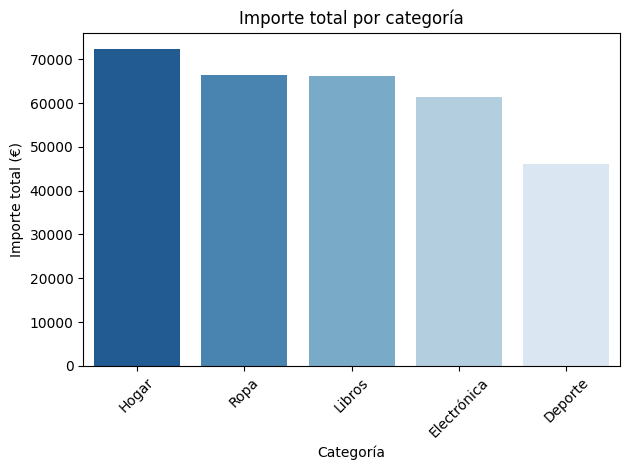

In [ ]:
# Your solution Here

import matplotlib.pyplot as plt
import seaborn as sns

# Importe total por categoría
ventas_categoria = (
    pedidos_validos
    .groupby('categoria')['importe']
    .sum()
    .sort_values(ascending=False)
)

sns.barplot(
    x=ventas_categoria.index,
    y=ventas_categoria.values,
    hue=ventas_categoria.index,
    palette='Blues_r',
    legend=False
)

plt.title('Importe total por categoría')
plt.xlabel('Categoría')
plt.ylabel('Importe total (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### 05.B (0.75pt)

Averigua los 5 clientes que más han gastado en total (la suma de la columna `importe`). Crea un gráfico de barras horizontal, mostrando su nombre, ciudad y gasto total.

In [ ]:
# Your solution Here
import matplotlib.pyplot as plt

# Top 5 clientes por gasto total
top_clientes = (
    pedidos_validos
    .groupby(['nombre', 'ciudad'], as_index=False)
    .agg(gasto_total=('importe', 'sum'))
    .sort_values('gasto_total', ascending=False)
    .head(5)
)

display(top_clientes)

# Etiquetas para el gráfico
top_clientes['etiqueta'] = (
    top_clientes['nombre'] + ' (' + top_clientes['ciudad'] + ')'
)


,nombre,ciudad,gasto_total
117,Raquel López,Sevilla,6161.05
90,Luis Romero,Bilbao,5662.21
128,Sergio Torres,Vigo,4808.77
67,Javier Navarro,Alicante,4625.16
63,Javier Díaz,Málaga,4589.63


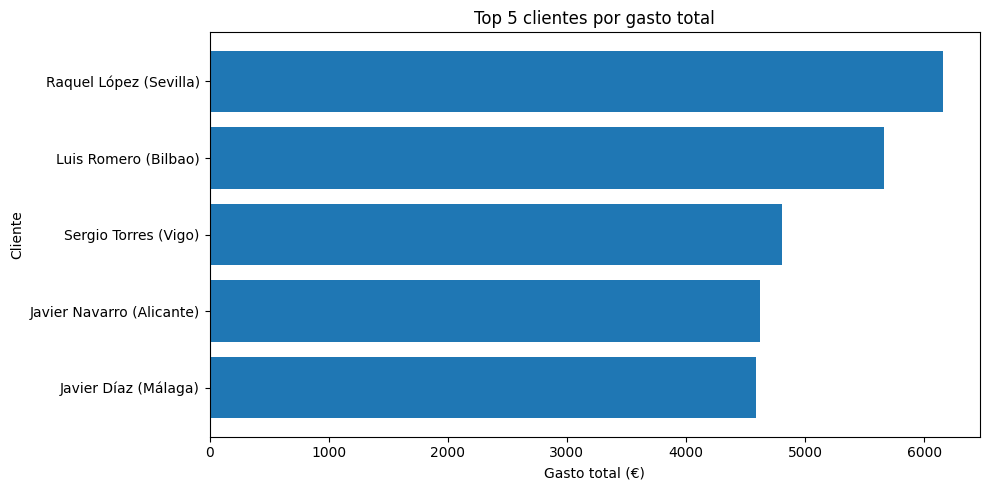

In [ ]:
# Your solution Here
# Gráfico de barras horizontal
plt.figure(figsize=(10, 5))
plt.barh(
    top_clientes['etiqueta'],
    top_clientes['gasto_total']
)
plt.title('Top 5 clientes por gasto total')
plt.xlabel('Gasto total (€)')
plt.ylabel('Cliente')
plt.gca().invert_yaxis()  # mayor gasto arriba
plt.tight_layout()
plt.show()